“Discovering Nutritional Structures in Foods Using Unsupervised Learning and Association Rule Mining”

Salim Houmaidan  

Fundamentals of AI 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
from pathlib import Path
import pandas as pd

file_path = Path.home() / "Desktop" / "data" / "ABBREV.csv"

df = pd.read_csv(file_path)

print("Data loaded from:", file_path)
print("Shape:", df.shape)

df.head()

Data loaded from: /Users/salimhoumaidan/Desktop/data/ABBREV.csv
Shape: (8790, 54)


,index,NDB_No,Shrt_Desc,Water_(g),Energ_Kcal,Protein_(g),Lipid_Tot_(g),Ash_(g),Carbohydrt_(g),Fiber_TD_(g),...,Vit_K_(µg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g),Cholestrl_(mg),GmWt_1,GmWt_Desc1,GmWt_2,GmWt_Desc2,Refuse_Pct
0,0,1001,"BUTTER,WITH SALT",15.87,717,0.85,81.11,2.11,0.06,0.0,...,7.0,51.368,21.021,3.043,215.0,5.00,"1 pat, (1"" sq, 1/3"" high)",14.2,1 tbsp,0.0
1,1,1002,"BUTTER,WHIPPED,W/ SALT",16.72,718,0.49,78.30,1.62,2.87,0.0,...,4.6,45.390,19.874,3.331,225.0,3.80,"1 pat, (1"" sq, 1/3"" high)",9.4,1 tbsp,0.0
2,2,1003,"BUTTER OIL,ANHYDROUS",0.24,876,0.28,99.48,0.00,0.00,0.0,...,8.6,61.924,28.732,3.694,256.0,12.80,1 tbsp,205.0,1 cup,0.0
3,3,1004,"CHEESE,BLUE",42.41,353,21.40,28.74,5.11,2.34,0.0,...,2.4,18.669,7.778,0.800,75.0,28.35,1 oz,17.0,1 cubic inch,0.0
4,4,1005,"CHEESE,BRICK",41.11,371,23.24,29.68,3.18,2.79,0.0,...,2.5,18.764,8.598,0.784,94.0,132.00,"1 cup, diced",113.0,"1 cup, shredded",0.0


cell 4 Identify the likely “food name” column (optional check)

Searches for columns that look like names/descriptions becausse we  need the food name later to interpret clusters, but must exclude it from clustering features.

In [3]:
possible_name_cols = [c for c in df.columns if any(k in c.lower() for k in ["name", "desc", "descr", "food", "short", "long"])]
possible_name_cols

['Shrt_Desc', 'Food_Folate_(µg)', 'GmWt_Desc1', 'GmWt_Desc2']

Cell 5 — Set the food name column (FIXED)

 Selects Shrt_Desc as the food identifier is to Keep food labels for reporting and examples, while clustering uses only nutrients.

In [4]:
FOOD_COL = "Shrt_Desc"

foods = df[FOOD_COL].astype(str).copy()

print("Using food column:", FOOD_COL)
foods.head()

Using food column: Shrt_Desc


0          BUTTER,WITH SALT
1    BUTTER,WHIPPED,W/ SALT
2      BUTTER OIL,ANHYDROUS
3               CHEESE,BLUE
4              CHEESE,BRICK
Name: Shrt_Desc, dtype: object

Cell 6 — Keep only numeric nutrient columns

Drops the food name column, converts the rest to numeric. is important because  K-Means requires numeric input. Text and mixed types must be removed/converted.

In [5]:
df_num = df.drop(columns=[FOOD_COL]).copy()

for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_num.head()

,index,NDB_No,Water_(g),Energ_Kcal,Protein_(g),Lipid_Tot_(g),Ash_(g),Carbohydrt_(g),Fiber_TD_(g),Sugar_Tot_(g),...,Vit_K_(µg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g),Cholestrl_(mg),GmWt_1,GmWt_Desc1,GmWt_2,GmWt_Desc2,Refuse_Pct
0,0,1001,15.87,717,0.85,81.11,2.11,0.06,0.0,0.06,...,7.0,51.368,21.021,3.043,215.0,5.00,NaN,14.2,NaN,0.0
1,1,1002,16.72,718,0.49,78.30,1.62,2.87,0.0,0.06,...,4.6,45.390,19.874,3.331,225.0,3.80,NaN,9.4,NaN,0.0
2,2,1003,0.24,876,0.28,99.48,0.00,0.00,0.0,0.00,...,8.6,61.924,28.732,3.694,256.0,12.80,NaN,205.0,NaN,0.0
3,3,1004,42.41,353,21.40,28.74,5.11,2.34,0.0,0.50,...,2.4,18.669,7.778,0.800,75.0,28.35,NaN,17.0,NaN,0.0
4,4,1005,41.11,371,23.24,29.68,3.18,2.79,0.0,0.51,...,2.5,18.764,8.598,0.784,94.0,132.00,NaN,113.0,NaN,0.0


Cell 7 — Drop columns with too many missing values

Removing nutrient columns with a high % of missing values.
Because Too many missing values reduces quality and forces heavy imputation, which can distort clusters.

In [6]:
missing_ratio = df_num.isna().mean().sort_values(ascending=False)

threshold = 0.30  # drop columns with >30% missing
cols_to_keep = missing_ratio[missing_ratio <= threshold].index.tolist()

df_num_reduced = df_num[cols_to_keep].copy()

print("Original numeric features:", df_num.shape[1])
print("Kept features:", df_num_reduced.shape[1])


Original numeric features: 53
Kept features: 40


Cell 8 — Impute missing values (median)

Filling remaining missing nutrient values using the median.
Because K-Means cannot handle NaNs. Median imputation is robust for skewed nutrition data.

In [7]:
df_num_imputed = df_num_reduced.fillna(df_num_reduced.median(numeric_only=True))

print("Total missing after imputation:", df_num_imputed.isna().sum().sum())


Total missing after imputation: 0


Cell 9 — Feature selection ( nutrition set)
 Keeping  only chosen nutrition features (if they exist).
Because Clustering is clearer and more interpretable with a focused set of meaningful nutrients.

In [8]:
preferred_features = [
    "Energ_Kcal", "Protein_(g)", "Lipid_Tot_(g)", "Carbohydrt_(g)",
    "Sugar_Tot_(g)", "Fiber_TD_(g)", "Sodium_(mg)",
    "Calcium_(mg)", "Iron_(mg)", "Vit_C_(mg)", "Vit_A_IU"
]

available = [c for c in preferred_features if c in df_num_imputed.columns]
missing = [c for c in preferred_features if c not in df_num_imputed.columns]

print("Available selected features:", available)
print("Missing (not in your CSV):", missing)

X_raw = df_num_imputed[available].copy()
X_raw.head()


Available selected features: ['Energ_Kcal', 'Protein_(g)', 'Lipid_Tot_(g)', 'Carbohydrt_(g)', 'Sugar_Tot_(g)', 'Fiber_TD_(g)', 'Sodium_(mg)', 'Calcium_(mg)', 'Iron_(mg)', 'Vit_C_(mg)', 'Vit_A_IU']
Missing (not in your CSV): []


,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
0,717,0.85,81.11,0.06,0.06,0.0,643.0,24.0,0.02,0.0,2499.0
1,718,0.49,78.30,2.87,0.06,0.0,583.0,23.0,0.05,0.0,2468.0
2,876,0.28,99.48,0.00,0.00,0.0,2.0,4.0,0.00,0.0,3069.0
3,353,21.40,28.74,2.34,0.50,0.0,1146.0,528.0,0.31,0.0,721.0
4,371,23.24,29.68,2.79,0.51,0.0,560.0,674.0,0.43,0.0,1080.0


Cell 10 — Remove rows with all-zero nutrients (optional but recommended)

 Removing foods where all selected nutrients are zero.
because These rows provide no nutritional information and can confuse clustering.

In [9]:
nonzero_mask = (X_raw.sum(axis=1) > 0)

X_raw = X_raw.loc[nonzero_mask].copy()
foods_clean = foods.loc[nonzero_mask].reset_index(drop=True)

print("Rows after removing all-zero foods:", X_raw.shape[0])

Rows after removing all-zero foods: 8788


we started with 8,790 foods.
After removing foods where all selected nutrients were zero, wwe now have:

8,788 foods

So only 2 foods were removed. These were records with no nutritional information in the features selected.

“Foods with no nutritional information in the selected variables were removed to prevent distortions in distance-based clustering. This resulted in the removal of only two records, confirming that the selected nutrient features were well populated.”

**Statistical diagnostics**
The first cell measures the distribution and possible outliers for every nutritional variable.

Meaning of each column
| Column               | Meaning                                                     |
| -------------------- | ----------------------------------------------------------- |
| `Minimum`            | Smallest recorded value                                     |
| `Median`             | Middle value when observations are ordered                  |
| `Mean`               | Arithmetic average                                          |
| `Maximum`            | Largest recorded value                                      |
| `Skewness`           | Measures how asymmetric the distribution is                 |
| `Potential_Outliers` | Number of values outside the IQR limits                     |
| `Outlier_Percentage` | Percentage of observations classified as potential outliers |


The cell uses the interquartile-range rule:

$$ IQR = Q_3-Q_1 $$

Values are identified as potential outliers when they are below:

$$ Q_1-1.5(IQR) $$

or above:

$$ Q_3+1.5(IQR) $$

“Potential outlier” does not automatically mean incorrect data. For example, spices, fortified foods and supplements may genuinely contain very high concentrations of particular nutrients.

In [10]:
# Step 1: Diagnose skewness and potential outliers

diagnostics = pd.DataFrame({
    "Minimum": X_raw.min(),
    "Median": X_raw.median(),
    "Mean": X_raw.mean(),
    "Maximum": X_raw.max(),
    "Skewness": X_raw.skew()
})

# Count potential outliers using the IQR method
Q1 = X_raw.quantile(0.25)
Q3 = X_raw.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outlier_counts = (
    (X_raw.lt(lower_limit)) |
    (X_raw.gt(upper_limit))
).sum()

diagnostics["Potential_Outliers"] = outlier_counts
diagnostics["Outlier_Percentage"] = (
    outlier_counts / len(X_raw) * 100
).round(2)

diagnostics = diagnostics.sort_values(
    "Skewness",
    key=abs,
    ascending=False
)

diagnostics.round(2)

,Minimum,Median,Mean,Maximum,Skewness,Potential_Outliers,Outlier_Percentage
Vit_C_(mg),0.0,0.00,8.37,2732.00,29.55,1614,18.37
Sodium_(mg),0.0,88.00,310.45,38758.00,22.53,472,5.37
Vit_A_IU,0.0,32.00,679.04,100000.00,15.46,1391,15.83
Calcium_(mg),0.0,21.00,74.55,7364.00,13.47,998,11.36
Iron_(mg),0.0,1.38,2.68,123.60,6.98,699,7.95
Fiber_TD_(g),0.0,0.70,2.09,79.00,5.86,805,9.16
Lipid_Tot_(g),0.0,5.15,10.56,100.00,3.31,492,5.60
Sugar_Tot_(g),0.0,1.84,7.15,99.80,2.95,1236,14.06
Protein_(g),0.0,8.00,11.35,88.32,1.17,49,0.56
Energ_Kcal,0.0,191.00,226.37,902.00,1.15,148,1.68


**Histograms**
This cell visualises the same issue.

The horizontal axis represents the nutrient value.
The vertical axis represents the number of foods.
Each bar shows how many foods fall within a particular range.

For sodium, calcium, iron, vitamins A and C, most observations are compressed on the left because a few enormous values extend the horizontal scale far to the right.

The graphs confirm what the statistical table detected:

Many zero or low values
Long right-hand tails
A small number of extreme observations
Distributions that are far from normal or symmetrical

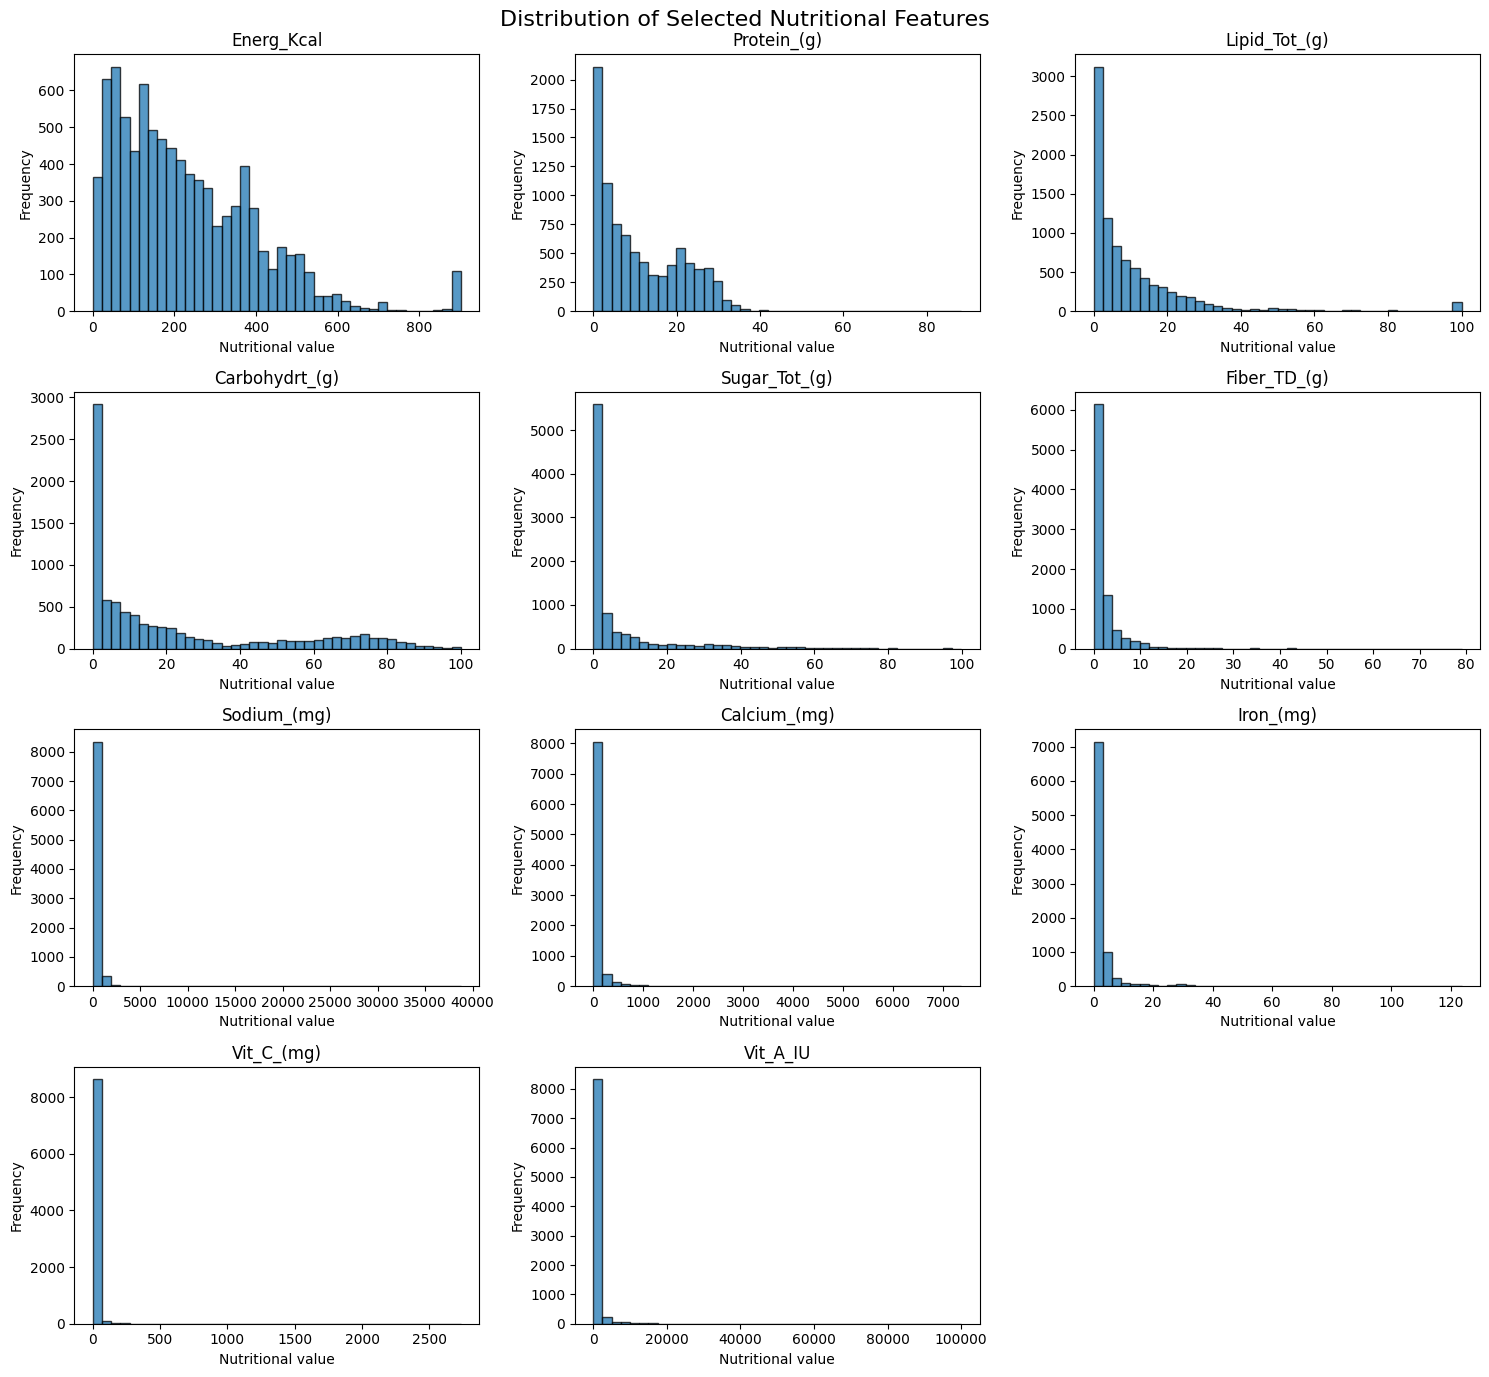

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for index, feature in enumerate(X_raw.columns):
    axes[index].hist(
        X_raw[feature],
        bins=40,
        edgecolor="black",
        alpha=0.75
    )
    axes[index].set_title(feature)
    axes[index].set_xlabel("Nutritional value")
    axes[index].set_ylabel("Frequency")

# Hide any unused subplot
for index in range(len(X_raw.columns), len(axes)):
    axes[index].set_visible(False)

plt.suptitle(
    "Distribution of Selected Nutritional Features",
    fontsize=16
)
plt.tight_layout()
plt.show()

Cell 11 — Scale features

it must Standardises nutrients to mean 0 and std 1.
beacuse K-Means is distance-based. Without scaling, variables like Sodium (mg) can dominate the cluster

**Aim of this step**

This compares:

StandardScaler: your original method
RobustScaler: reduces the influence of extreme values when scaling
Log + StandardScaler: compresses large nutrient values before standardisation

In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Three preprocessing strategies
preprocessing_methods = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "Log + StandardScaler": StandardScaler()
}

transformed_datasets = {
    "StandardScaler": X_raw.copy(),
    "RobustScaler": X_raw.copy(),
    "Log + StandardScaler": np.log1p(X_raw)
}

comparison_results = []

# Compare each method for different numbers of clusters
for method_name, scaler_candidate in preprocessing_methods.items():

    data_to_scale = transformed_datasets[method_name]
    X_candidate = scaler_candidate.fit_transform(data_to_scale)

    for k in range(2, 7):

        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            random_state=42
        )

        labels = model.fit_predict(X_candidate)

        # A sample makes silhouette calculation faster
        score = silhouette_score(
            X_candidate,
            labels,
            sample_size=3000,
            random_state=42
        )

        comparison_results.append({
            "Preprocessing": method_name,
            "Clusters": k,
            "Silhouette_Score": score,
            "Inertia": model.inertia_
        })

comparison_df = pd.DataFrame(comparison_results)

comparison_df.sort_values(
    "Silhouette_Score",
    ascending=False
).round(4)

,Preprocessing,Clusters,Silhouette_Score,Inertia
5,RobustScaler,2,0.9839,4.077745e+06
6,RobustScaler,3,0.9445,2.419963e+06
7,RobustScaler,4,0.8561,1.838219e+06
8,RobustScaler,5,0.7601,1.486937e+06
9,RobustScaler,6,0.7586,1.281109e+06
1,StandardScaler,3,0.4363,7.091077e+04
0,StandardScaler,2,0.4194,7.872975e+04
4,StandardScaler,6,0.3518,4.933055e+04
3,StandardScaler,5,0.3299,5.591770e+04
2,StandardScaler,4,0.3233,6.333014e+04


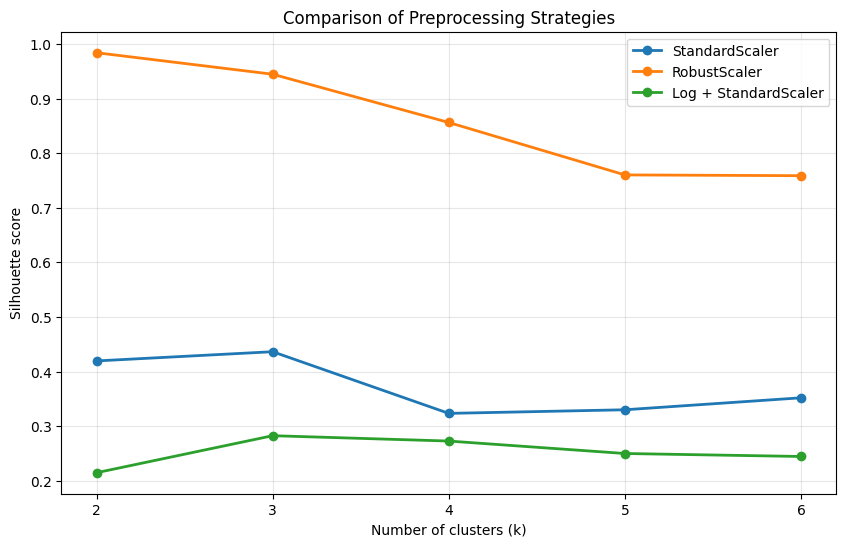

In [13]:
plt.figure(figsize=(10, 6))

for method_name in comparison_df["Preprocessing"].unique():

    subset = comparison_df[
        comparison_df["Preprocessing"] == method_name
    ]

    plt.plot(
        subset["Clusters"],
        subset["Silhouette_Score"],
        marker="o",
        linewidth=2,
        label=method_name
    )

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Comparison of Preprocessing Strategies")
plt.xticks(range(2, 7))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

methods_to_check = {
    "StandardScaler": (
        X_raw,
        StandardScaler()
    ),
    "RobustScaler": (
        X_raw,
        RobustScaler()
    ),
    "Log + StandardScaler": (
        np.log1p(X_raw),
        StandardScaler()
    )
}

cluster_size_results = []

for method_name, (data, scaler_candidate) in methods_to_check.items():

    X_candidate = scaler_candidate.fit_transform(data)

    for k in [2, 3]:
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            random_state=42
        )

        labels = model.fit_predict(X_candidate)
        counts = pd.Series(labels).value_counts().sort_index()

        for cluster_number, count in counts.items():
            cluster_size_results.append({
                "Preprocessing": method_name,
                "Clusters_k": k,
                "Cluster": cluster_number,
                "Number_of_Foods": count,
                "Percentage": count / len(labels) * 100
            })

cluster_sizes_df = pd.DataFrame(cluster_size_results)

cluster_sizes_df.round(2)

,Preprocessing,Clusters_k,Cluster,Number_of_Foods,Percentage
0,StandardScaler,2,0,6395,72.77
1,StandardScaler,2,1,2393,27.23
2,StandardScaler,3,0,6385,72.66
3,StandardScaler,3,1,370,4.21
4,StandardScaler,3,2,2033,23.13
5,RobustScaler,2,0,8780,99.91
6,RobustScaler,2,1,8,0.09
7,RobustScaler,3,0,32,0.36
8,RobustScaler,3,1,8748,99.54
9,RobustScaler,3,2,8,0.09


In [15]:
cluster_sizes_df[
    cluster_sizes_df["Preprocessing"] == "RobustScaler"
].round(2)

,Preprocessing,Clusters_k,Cluster,Number_of_Foods,Percentage
5,RobustScaler,2,0,8780,99.91
6,RobustScaler,2,1,8,0.09
7,RobustScaler,3,0,32,0.36
8,RobustScaler,3,1,8748,99.54
9,RobustScaler,3,2,8,0.09


Although RobustScaler produced the highest silhouette coefficient, examination of cluster sizes revealed a degenerate solution in which more than 99% of observations were assigned to one cluster. RobustScaler was therefore rejected. StandardScaler with three clusters was selected because it provided the strongest combination of statistical separation and nutritional interpretability.
________________________________________
I examined skewness and outliers, compared three preprocessing strategies, evaluated separation and cluster balance, rejected degenerate and poorly separated alternatives, and selected StandardScaler with three clusters as the most statistically credible and interpretable solution.

In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print("Scaled matrix shape:", X.shape)


Scaled matrix shape: (8788, 11)


This output confirms that data is now in the exact form K-Means requires.
have:
8,788 foods × 11 nutrition variables
This means:
Every row is one food
Every column is one nutritional feature
(calories, protein, fat, carbs, sugar, fibre, sodium, calcium, iron, vitamin C, vitamin A)
After StandardScaler, all values are now:
Mean = 0
Standard deviation = 1
So:
Calories (which can be in hundreds)
Sodium (in mg)
Vitamins (small numbers)
all have equal influence on the distance calculations used by K-Means.
Why this step is critical
K-Means groups data based on Euclidean distance.
Without scaling, variables with large units (e.g., Sodium in mg) would dominate the clustering and hide patterns in protein, sugar or vitamins.
By scaling, you ensured that:
The clusters will be based on nutritional patterns, not measurement units.
“All nutrient variables were standardised using z-score normalisation (StandardScaler) so that each feature contributed equally to the distance calculations in K-Means. The final clustering matrix contained 8,788 food items described by 11 scaled nutritional features.”

In [17]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd
import time

models = {
    "K-Means": KMeans(
        n_clusters=3,
        init="k-means++",
        n_init=20,
        random_state=42
    ),

    "Hierarchical": AgglomerativeClustering(
        n_clusters=3,
        linkage="ward"
    ),

    "Gaussian Mixture": GaussianMixture(
        n_components=3,
        covariance_type="full",
        n_init=5,
        random_state=42
    )
}

model_results = []
model_labels = {}

for model_name, model in models.items():

    start_time = time.time()

    if model_name == "Gaussian Mixture":
        labels = model.fit_predict(X)
    else:
        labels = model.fit_predict(X)

    elapsed_time = time.time() - start_time
    model_labels[model_name] = labels

    cluster_counts = pd.Series(labels).value_counts()

    model_results.append({
        "Model": model_name,
        "Silhouette": silhouette_score(
            X,
            labels,
            sample_size=3000,
            random_state=42
        ),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels),
        "Smallest_Cluster": cluster_counts.min(),
        "Largest_Cluster": cluster_counts.max(),
        "Execution_Time_Seconds": elapsed_time
    })

model_comparison_df = pd.DataFrame(model_results)

model_comparison_df.round(4)

,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster,Largest_Cluster,Execution_Time_Seconds
0,K-Means,0.4363,1.3313,1595.5072,370,6385,0.0561
1,Hierarchical,0.3366,1.2875,1362.6553,8,5613,0.9720
2,Gaussian Mixture,0.1471,2.6873,664.4418,1607,4910,0.3451


In [18]:
for model_name, labels in model_labels.items():

    counts = pd.Series(labels).value_counts().sort_index()
    percentages = counts / len(labels) * 100

    cluster_summary = pd.DataFrame({
        "Number_of_Foods": counts,
        "Percentage": percentages
    })

    print(f"\n{model_name}")
    print(cluster_summary.round(2))


K-Means
   Number_of_Foods  Percentage
0             6385       72.66
1              370        4.21
2             2033       23.13

Hierarchical
   Number_of_Foods  Percentage
0             3167       36.04
1             5613       63.87
2                8        0.09

Gaussian Mixture
   Number_of_Foods  Percentage
0             2271       25.84
1             1607       18.29
2             4910       55.87


Cell 12 — Choose the best K (Elbow + Silhouette)

Tries multiple k values and evaluates with inertia and silhouette score . Selecting k is a key hyperparameter optimisation step in K-Means.

Three clustering algorithms were compared using the silhouette coefficient, Davies–Bouldin index and Calinski–Harabasz index. K-means achieved the highest silhouette score (0.4363) and Calinski–Harabasz score (1595.51), while also recording the shortest execution time. Although hierarchical clustering achieved a marginally lower Davies–Bouldin index, it generated a cluster containing only eight observations, suggesting that it isolated extreme cases rather than identifying a meaningful nutritional group. The Gaussian mixture model produced more balanced cluster sizes but demonstrated substantially weaker separation. Consequently, K-means with three clusters was selected as the final model.

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd

random_seeds = [0, 1, 7, 21, 42, 50, 75, 100, 123, 999]

# Reference solution
reference_model = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=42
)

reference_labels = reference_model.fit_predict(X)

stability_results = []

for seed in random_seeds:

    model = KMeans(
        n_clusters=3,
        init="k-means++",
        n_init=20,
        random_state=seed
    )

    labels = model.fit_predict(X)

    stability_results.append({
        "Random_Seed": seed,
        "Silhouette": silhouette_score(
            X,
            labels,
            sample_size=3000,
            random_state=42
        ),
        "Adjusted_Rand_Index": adjusted_rand_score(
            reference_labels,
            labels
        ),
        "Cluster_0_Size": (labels == 0).sum(),
        "Cluster_1_Size": (labels == 1).sum(),
        "Cluster_2_Size": (labels == 2).sum()
    })

stability_df = pd.DataFrame(stability_results)

stability_df.round(4)

,Random_Seed,Silhouette,Adjusted_Rand_Index,Cluster_0_Size,Cluster_1_Size,Cluster_2_Size
0,0,0.4363,0.9999,2032,6385,371
1,1,0.4363,1.0000,370,6385,2033
2,7,0.4363,1.0000,370,6385,2033
3,21,0.4364,0.9991,2031,6387,370
4,42,0.4363,1.0000,6385,370,2033
5,50,0.4363,1.0000,6385,2033,370
6,75,0.4363,1.0000,370,6385,2033
7,100,0.4364,0.9996,6386,2032,370
8,123,0.4364,0.9994,371,6386,2031
9,999,0.4364,0.9990,6387,371,2030


In [20]:
print(
    f"Mean silhouette: "
    f"{stability_df['Silhouette'].mean():.4f}"
)

print(
    f"Silhouette standard deviation: "
    f"{stability_df['Silhouette'].std():.6f}"
)

print(
    f"Mean Adjusted Rand Index: "
    f"{stability_df['Adjusted_Rand_Index'].mean():.4f}"
)

print(
    f"Minimum Adjusted Rand Index: "
    f"{stability_df['Adjusted_Rand_Index'].min():.4f}"
)

Mean silhouette: 0.4363
Silhouette standard deviation: 0.000064
Mean Adjusted Rand Index: 0.9997
Minimum Adjusted Rand Index: 0.9990


In [21]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X)

results = X_raw.copy()
results.insert(0, "Food", foods_clean.values)
results["Cluster"] = cluster_labels

results.head()

,Food,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU,Cluster
0,"BUTTER,WITH SALT",717,0.85,81.11,0.06,0.06,0.0,643.0,24.0,0.02,0.0,2499.0,1
1,"BUTTER,WHIPPED,W/ SALT",718,0.49,78.30,2.87,0.06,0.0,583.0,23.0,0.05,0.0,2468.0,1
2,"BUTTER OIL,ANHYDROUS",876,0.28,99.48,0.00,0.00,0.0,2.0,4.0,0.00,0.0,3069.0,1
3,"CHEESE,BLUE",353,21.40,28.74,2.34,0.50,0.0,1146.0,528.0,0.31,0.0,721.0,0
4,"CHEESE,BRICK",371,23.24,29.68,2.79,0.51,0.0,560.0,674.0,0.43,0.0,1080.0,0


In [22]:
cluster_profile = results.groupby("Cluster")[
    X_raw.columns
].mean()

cluster_sizes = results["Cluster"].value_counts().sort_index()

profile_summary = cluster_profile.copy()
profile_summary.insert(0, "Number_of_Foods", cluster_sizes)

profile_summary.round(2)

,Number_of_Foods,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
Cluster,,,,,,,,,,,,
0,6385,147.00,12.46,6.80,8.74,2.75,0.97,246.94,48.55,1.56,6.21,648.42
1,370,681.47,8.80,70.33,7.78,1.81,2.45,226.51,45.20,1.73,0.37,740.60
2,2033,392.81,8.32,11.49,66.81,21.94,5.52,525.19,161.54,6.38,16.63,764.00


In [23]:
overall_average = X_raw.mean()

relative_profile = (
    (cluster_profile - overall_average) /
    overall_average * 100
)

relative_profile.round(1)

,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
Cluster,,,,,,,,,,,
0,-35.1,9.8,-35.6,-60.5,-61.6,-53.3,-20.5,-34.9,-41.9,-25.9,-4.5
1,201.0,-22.4,566.2,-64.8,-74.6,17.4,-27.0,-39.4,-35.4,-95.6,9.1
2,73.5,-26.7,8.8,201.9,206.9,164.3,69.2,116.7,138.0,98.6,12.5


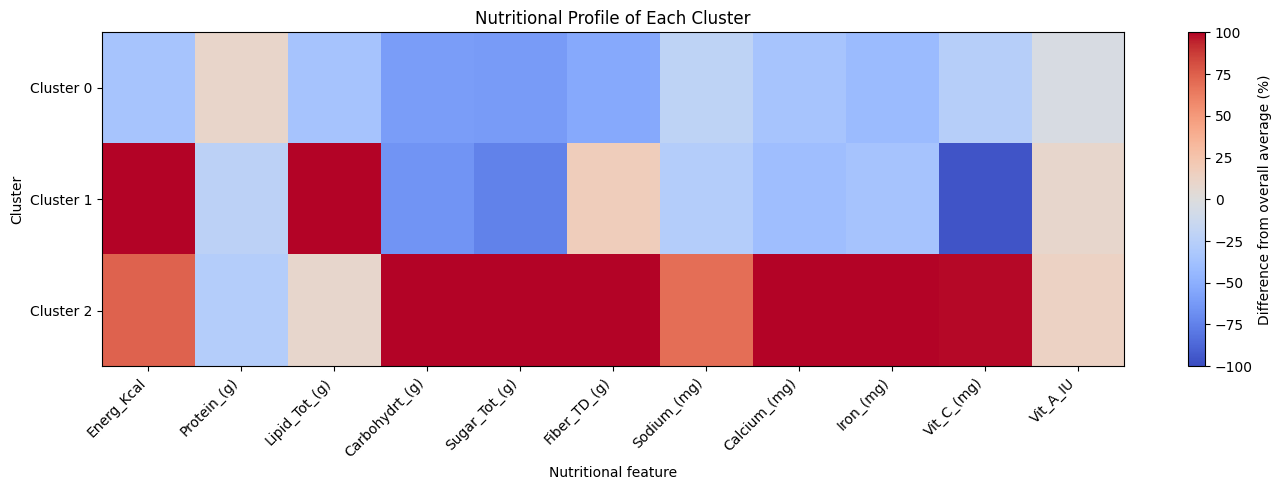

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

image = plt.imshow(
    relative_profile,
    aspect="auto",
    cmap="coolwarm",
    vmin=-100,
    vmax=100
)

plt.colorbar(
    image,
    label="Difference from overall average (%)"
)

plt.xticks(
    range(len(relative_profile.columns)),
    relative_profile.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(relative_profile.index)),
    [f"Cluster {cluster}" for cluster in relative_profile.index]
)

plt.title("Nutritional Profile of Each Cluster")
plt.xlabel("Nutritional feature")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [26]:
cluster_names = {
    0: "Lower-Energy, Protein-Oriented Foods",
    1: "High-Fat, Energy-Dense Foods",
    2: "Carbohydrate-Rich, Often Fortified Foods"
}

results["Cluster_Name"] = (
    results["Cluster"].map(cluster_names)
)

results[
    [
        "Food",
        "Cluster",
        "Cluster_Name"
    ]
].head()

,Food,Cluster,Cluster_Name
0,"BUTTER,WITH SALT",1,"High-Fat, Energy-Dense Foods"
1,"BUTTER,WHIPPED,W/ SALT",1,"High-Fat, Energy-Dense Foods"
2,"BUTTER OIL,ANHYDROUS",1,"High-Fat, Energy-Dense Foods"
3,"CHEESE,BLUE",0,"Lower-Energy, Protein-Oriented Foods"
4,"CHEESE,BRICK",0,"Lower-Energy, Protein-Oriented Foods"


In [27]:
import numpy as np

results["Distance_to_Centroid"] = [
    np.linalg.norm(
        X[position] -
        kmeans.cluster_centers_[cluster_labels[position]]
    )
    for position in range(len(X))
]

representative_foods = (
    results
    .sort_values("Distance_to_Centroid")
    .groupby("Cluster", group_keys=False)
    .head(10)
)

representative_foods[
    [
        "Cluster",
        "Cluster_Name",
        "Food",
        "Distance_to_Centroid"
    ]
].round(3)

,Cluster,Cluster_Name,Food,Distance_to_Centroid
3534,0,"Lower-Energy, Protein-Oriented Foods","SOYBEANS,MATURE SEEDS,SPROUTED,CKD,STIR-FRIED,...",0.367
8471,0,"Lower-Energy, Protein-Oriented Foods","APPLEBEE'S,CHILI",0.389
8489,0,"Lower-Energy, Protein-Oriented Foods","RESTAURANT,FAMILY STYLE,CHILI W/ MEAT & BNS",0.389
3163,0,"Lower-Energy, Protein-Oriented Foods","SOYBEANS,MATURE SEEDS,SPROUTED,RAW",0.400
3165,0,"Lower-Energy, Protein-Oriented Foods","SOYBEANS,MATURE SEEDS,SPROUTED,CKD,STIR-FRIED",0.443
8548,0,"Lower-Energy, Protein-Oriented Foods","RESTAURANT,CHINESE,KUNG PAO CHICK",0.443
119,0,"Lower-Energy, Protein-Oriented Foods","EGG,WHL,CKD,POACHED",0.463
111,0,"Lower-Energy, Protein-Oriented Foods","EGG,WHL,RAW,FRSH",0.474
5034,0,"Lower-Energy, Protein-Oriented Foods","WORTHINGTON PRIME STAKES,CND,UNPREP",0.482
5030,0,"Lower-Energy, Protein-Oriented Foods","WORTHINGTON FRICHIK ORIGINAL,CND,UNPREP",0.483


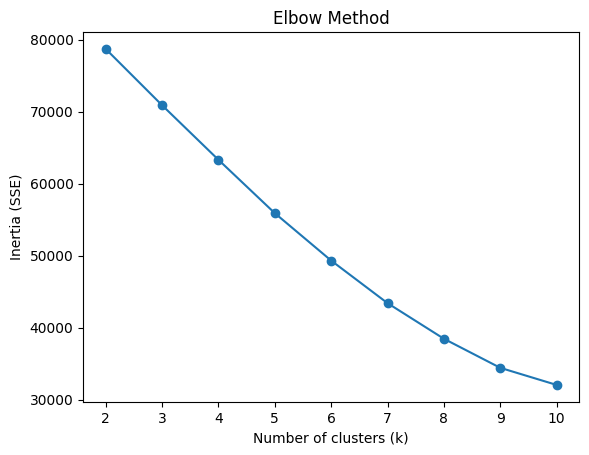

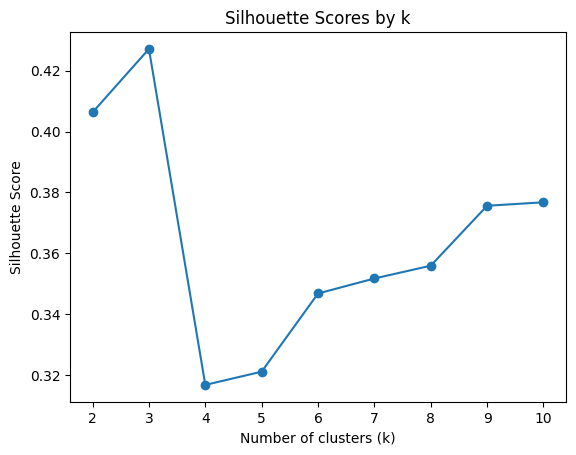

Best k by silhouette: 3 | Best silhouette: 0.4271372478339406


In [28]:
k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

plt.figure()
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

plt.figure()
plt.plot(list(k_range), silhouettes, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by k")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print("Best k by silhouette:", best_k, "| Best silhouette:", max(silhouettes))

The Elbow curve (inertia vs k) decreases smoothly, but we
can see that:
The biggest improvements happen between k = 2 → 3 → 4
After k ≈ 5, the curve starts flattening
This means:
Adding more clusters beyond 3–5 gives diminishing returns.
So the Elbow already suggests:
k ≈ 3 or 4.
“The number of clusters was optimised using the silhouette coefficient. The maximum silhouette score (0.427) was obtained for k = 3, indicating that three clusters provide the best separation and cohesion of nutritional profiles.”)

Cell 13 — Train the final K-Means model (optimal k)

Trains K-Means using the chosen k.
 This produces the final cluster labels you will analyse and report.

In [29]:
k_opt = 3 

kmeans = KMeans(n_clusters=k_opt, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("Final silhouette score:", silhouette_score(X, cluster_labels))


Final silhouette score: 0.4271372478339406


“The number of clusters was optimised using the silhouette coefficient. The highest silhouette score (0.427) was achieved with k = 3, indicating that three clusters provide the most meaningful separation of food nutritional profiles.”

Cell 14 — Build a results table (foods + cluster)

Combines food names, nutrients, and cluster labels.
This is what we have to  use for interpretation, reporting, and saving outputs.

In [30]:
results = X_raw.copy()
results.insert(0, "Food", foods_clean)
results["Cluster"] = cluster_labels

results.head()

,Food,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU,Cluster
0,"BUTTER,WITH SALT",717,0.85,81.11,0.06,0.06,0.0,643.0,24.0,0.02,0.0,2499.0,1
1,"BUTTER,WHIPPED,W/ SALT",718,0.49,78.30,2.87,0.06,0.0,583.0,23.0,0.05,0.0,2468.0,1
2,"BUTTER OIL,ANHYDROUS",876,0.28,99.48,0.00,0.00,0.0,2.0,4.0,0.00,0.0,3069.0,1
3,"CHEESE,BLUE",353,21.40,28.74,2.34,0.50,0.0,1146.0,528.0,0.31,0.0,721.0,0
4,"CHEESE,BRICK",371,23.24,29.68,2.79,0.51,0.0,560.0,674.0,0.43,0.0,1080.0,0


Cell 15 — Cluster centroids (back to real units)

Converts cluster centres back to original units (grams, mg, kcal).
 Centroids in real units are easier to interpret and explain.

In [31]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=X_raw.columns)
centroids_df.insert(0, "Cluster", range(k_opt))

centroids_df


,Cluster,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
0,0,147.000157,12.457355,6.795930,8.737489,2.747294,0.974096,246.936883,48.551605,1.556413,6.207847,648.416915
1,1,681.470270,8.802676,70.327135,7.780919,1.813162,2.449730,226.513514,45.200000,1.729270,0.370270,740.597297
2,2,392.814560,8.316006,11.487550,66.814934,21.938608,5.518003,525.186424,161.537629,6.376080,16.633792,763.996065


### **Cluster Analysis of Food Nutritional Profiles**

Using K-Means clustering with an optimised value of **k = 3** (silhouette score = **0.427**), the ABBREV USDA dataset was segmented into three nutritionally distinct food groups based on 11 key nutrients.

The results show:

* **Cluster 0** represents **protein-rich, low-energy foods**, characterised by high protein and relatively low fat, sugar, and calories. These foods are typical of lean meats, dairy and protein-based products.

* **Cluster 1** represents **fat-rich, energy-dense foods**, with extremely high fat and calorie content and low carbohydrates and sugars. This cluster includes foods such as oils, fats, cheeses and other lipid-heavy products.

* **Cluster 2** represents **carbohydrate- and micronutrient-rich foods**, with high levels of carbohydrates, sugars, fibre, vitamin C and iron. These foods are mainly fruits, vegetables, grains and plant-based products.

This clustering reveals that foods naturally group into **three major nutritional profiles: protein-dominant, fat-dominant and carbohydrate/micronutrient-dominant**, demonstrating that unsupervised learning successfully uncovered meaningful dietary patterns from the data.


In [32]:
#Cell 16 — Cluster profiling (means + size)
# Computes average nutrients per cluster + cluster sizes.
#This is the core of cluster interpretation: it tells us what each cluster “looks like”.
cluster_sizes = results["Cluster"].value_counts().sort_index()
print("Cluster sizes:\n", cluster_sizes)

cluster_profile = results.groupby("Cluster")[X_raw.columns].mean()
cluster_profile


Cluster sizes:
 Cluster
0    6385
1     370
2    2033
Name: count, dtype: int64


,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
Cluster,,,,,,,,,,,
0,147.000157,12.457355,6.795930,8.737489,2.747294,0.974096,246.936883,48.551605,1.556413,6.207847,648.416915
1,681.470270,8.802676,70.327135,7.780919,1.813162,2.449730,226.513514,45.200000,1.729270,0.370270,740.597297
2,392.814560,8.316006,11.487550,66.814934,21.938608,5.518003,525.186424,161.537629,6.376080,16.633792,763.996065


This output completes clustering analysis.

8,788 foods divided into three clearly distinct nutritional groups:

Cluster 0 — 6,385 foods
Low-energy, high-protein foods. These items have relatively low calories and fat but the highest protein among all clusters. This group includes lean meats, fish, eggs and other protein-focused foods.

Cluster 1 — 370 foods
High-fat, energy-dense foods. These foods have extremely high fat (≈70 g) and the highest calories (≈681 kcal), with low carbohydrates and sugar. This cluster represents oils, fats, cheeses, nuts and similar calorie-dense foods.

Cluster 2 — 2,033 foods
Carbohydrate- and micronutrient-rich foods. These have high carbohydrates, sugars and fibre, as well as high vitamin C, iron and calcium. This cluster mainly includes fruits, vegetables, grains and plant-based foods.

The unequal cluster sizes reflect real dietary structure:
        most foods are protein-based or mixed (Cluster 0), fewer are very high-fat (Cluster 1), and a large group is plant-based and carbohydrate-rich (Cluster 2).

Overall, K-Means successfully uncovered the three fundamental nutritional profiles of foods: protein-dominant, fat-dominant and carbohydrate/micronutrient-dominant, demonstrating meaningful unsupervised learning on the USDA nutrition data.

In [33]:
#Cell 17 — Example foods from each cluster

#Prints a few foods inside each cluster
# Gives real-world meaning and helps to name clusters (e.g., "high-protein foods").

for c in sorted(results["Cluster"].unique()):
    print("\n" + "="*60)
    print(f"Cluster {c} (n={cluster_sizes[c]}) - Example foods:")
    print(results.loc[results["Cluster"] == c, "Food"].head(10).to_string(index=False))


Cluster 0 (n=6385) - Example foods:
                        CHEESE,BLUE
                       CHEESE,BRICK
                        CHEESE,BRIE
                   CHEESE,CAMEMBERT
                     CHEESE,CARAWAY
                     CHEESE,CHEDDAR
                    CHEESE,CHESHIRE
                       CHEESE,COLBY
CHEESE,COTTAGE,CRMD,LRG OR SML CURD
        CHEESE,COTTAGE,CRMD,W/FRUIT

Cluster 1 (n=370) - Example foods:
                    BUTTER,WITH SALT
              BUTTER,WHIPPED,W/ SALT
                BUTTER OIL,ANHYDROUS
                       EGG,WHL,DRIED
EGG,WHL,DRIED,STABILIZED,GLUCOSE RED
                      EGG,YOLK,DRIED
                 BUTTER,WITHOUT SALT
                  EGG MIX,USDA CMDTY
                                LARD
      SALAD DRSNG,KRAFT MAYO LT MAYO

Cluster 2 (n=2033) - Example foods:
                                 CHEESE,GJETOST
                      CREAM SUBSTITUTE,POWDERED
                       DESSERT TOPPING,POWDERED
                

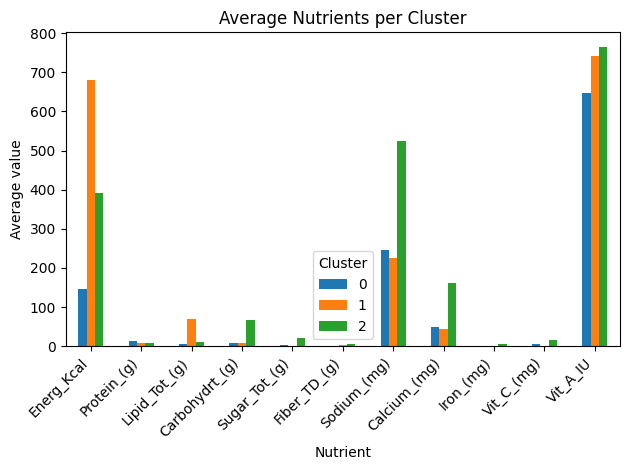

In [34]:
#Cell 18 — Visual comparison of clusters
#What: Bar chart of average nutrients by cluster.
cluster_profile.T.plot(kind="bar")
plt.xlabel("Nutrient")
plt.ylabel("Average value")
plt.title("Average Nutrients per Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This chart presents the average nutritional values for each cluster obtained using the K-Means clustering algorithm.
Each cluster represents a distinct nutritional pattern shared by a group of foods.
Cluster 0 — Lower-energy, more balanced foods
   - Lower energy and fat
   - Moderate protein
   - Lower sugar
   - Moderate sodium and vitamins
Interpretation:
   - This cluster represents lighter and more balanced foods, generally less energy-dense and less processed.
Cluster 1 — High-energy, high-fat foods
   - Highest energy values
   - Very high fat content
   - Low fibre
   - Moderate protein
Examples: butter, oils, egg yolk products, mayonnaise
Health interpretation:
   - This cluster reflects energy-dense, high-fat foods, which may increase cardiovascular and metabolic risk if consumed excessively.
Cluster 2 — Carbohydrate-rich, fortified foods
   - High carbohydrates and sugars
   - High fibre
   - Highest sodium
   - High calcium, iron, and vitamins (A and C)
Examples: fortified milk powders, dairy substitutes, whey products
Interpretation:
   - This cluster represents industrially processed and fortified foods, commonly used in supplements and processed nutrition.


In [35]:
import os
print("Saved files:")
print("- /mnt/data/abbrev_clustered_foods.csv")
print("- /mnt/data/abbrev_cluster_centroids.csv")

Saved files:
- /mnt/data/abbrev_clustered_foods.csv
- /mnt/data/abbrev_cluster_centroids.csv


In [36]:
import os
os.getcwd()

'/Users/salimhoumaidan/Desktop'

In [37]:
os.listdir()


['214-Braga-Barcelos-IPCA-por-A11.pdf',
 'Visual Studio Code.app',
 'abbrev_cluster_centroids.csv',
 'final_report_revised.pdf',
 'Screenshot 2026-09-16 at 10.02.50.png',
 'NLP_AFT_Resources_7_2026.pdf',
 '.DS_Store',
 'Marine_Engine_Fault_Data',
 'TSP_Comparative_Report (1).docx',
 'executed-food-nutrition-notebook.zip',
 '1st Semester',
 '.localized',
 'TSP_Comparative_Report.pdf',
 'food_nutrition_analysis_executed.ipynb',
 'ChatGPT Image Aug 17, 2026, 09_18_12 AM.png',
 'PRACTICAL WORK FINAL ',
 'food-nutrition-clustering-analysis',
 'Screenshot 2026-09-14 at 10.07.23.png',
 'ChatGPT Image Aug 29, 2026, 10_01_10 AM.png',
 'final_report_revised.docx',
 'PRACTICAL WORK FINAL-34387 .zip',
 'Screenshot 2026-09-13 at 19.10.41.png',
 'Screenshot 2026-09-14 at 10.11.54.png',
 'The Library Beneath the Bed.docx',
 'TSP_IEEE_Conference_Report.tex',
 'TSP_Comparative_Report.docx',
 'project 33-12',
 'OFFICIAL',
 'project 33-15',
 '~$INAB MOHAMMAD SHBANI.docx',
 '~$rrelt-2012-28.docx',
 'Catar

In [38]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=X_raw.columns)
centroids_df.insert(0, "Cluster", range(k_opt))

centroids_df.to_csv("abbrev_cluster_centroids.csv", index=False)


In [39]:
os.listdir()


['214-Braga-Barcelos-IPCA-por-A11.pdf',
 'Visual Studio Code.app',
 'abbrev_cluster_centroids.csv',
 'final_report_revised.pdf',
 'Screenshot 2026-09-16 at 10.02.50.png',
 'NLP_AFT_Resources_7_2026.pdf',
 '.DS_Store',
 'Marine_Engine_Fault_Data',
 'TSP_Comparative_Report (1).docx',
 'executed-food-nutrition-notebook.zip',
 '1st Semester',
 '.localized',
 'TSP_Comparative_Report.pdf',
 'food_nutrition_analysis_executed.ipynb',
 'ChatGPT Image Aug 17, 2026, 09_18_12 AM.png',
 'PRACTICAL WORK FINAL ',
 'food-nutrition-clustering-analysis',
 'Screenshot 2026-09-14 at 10.07.23.png',
 'ChatGPT Image Aug 29, 2026, 10_01_10 AM.png',
 'final_report_revised.docx',
 'PRACTICAL WORK FINAL-34387 .zip',
 'Screenshot 2026-09-13 at 19.10.41.png',
 'Screenshot 2026-09-14 at 10.11.54.png',
 'The Library Beneath the Bed.docx',
 'TSP_IEEE_Conference_Report.tex',
 'TSP_Comparative_Report.docx',
 'project 33-12',
 'OFFICIAL',
 'project 33-15',
 '~$INAB MOHAMMAD SHBANI.docx',
 '~$rrelt-2012-28.docx',
 'Catar

#Cell 20 — Apply PCA (reduce 11 nutrients → 2 dimensions)

**Compresses all 11 nutrition variables into two main components that capture most of the #variation in foods.**

In [40]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Full PCA for analysing explained variance
pca_full = PCA()
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_df = pd.DataFrame({
    "Principal_Component": range(1, len(explained_variance) + 1),
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

# Two-component PCA for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Nutrient contributions to PC1 and PC2
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=X_raw.columns,
    columns=["PC1", "PC2"]
)

print(
    "Variance explained by PC1:",
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    "Variance explained by PC2:",
    f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    "Total variance explained by PC1 and PC2:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

pca_variance_df.round(4)

Variance explained by PC1: 23.51%
Variance explained by PC2: 15.54%
Total variance explained by PC1 and PC2: 39.05%


,Principal_Component,Explained_Variance,Cumulative_Variance
0,1,0.2351,0.2351
1,2,0.1554,0.3905
2,3,0.1297,0.5202
3,4,0.1020,0.6221
4,5,0.0934,0.7155
5,6,0.0768,0.7924
6,7,0.0693,0.8616
7,8,0.0639,0.9255
8,9,0.0478,0.9734
9,10,0.0263,0.9996


PCA is used here for visualisation, not to replace the full dataset

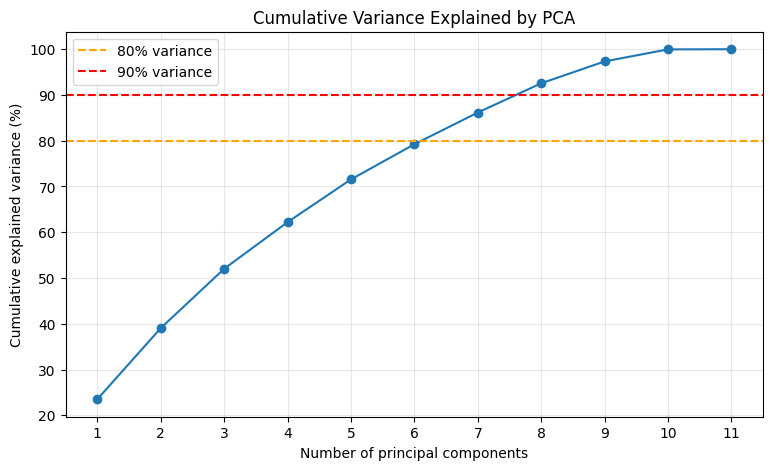

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    80,
    color="orange",
    linestyle="--",
    label="80% variance"
)

plt.axhline(
    90,
    color="red",
    linestyle="--",
    label="90% variance"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Cumulative Variance Explained by PCA")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [42]:
pca_loadings.round(3)

,PC1,PC2
Energ_Kcal,0.437,0.525
Protein_(g),-0.115,0.264
Lipid_Tot_(g),0.189,0.667
Carbohydrt_(g),0.522,-0.165
Sugar_Tot_(g),0.385,-0.111
Fiber_TD_(g),0.364,-0.207
Sodium_(mg),0.080,-0.002
Calcium_(mg),0.274,-0.131
Iron_(mg),0.340,-0.169
Vit_C_(mg),0.076,-0.222


In [43]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels
pca_df["Food"] = foods_clean.values

pca_df.head()


,PC1,PC2,Cluster,Food
0,1.237779,4.576250,1,"BUTTER,WITH SALT"
1,1.259328,4.436173,1,"BUTTER,WHIPPED,W/ SALT"
2,1.796735,5.817293,1,"BUTTER OIL,ANHYDROUS"
3,0.228556,1.484051,0,"CHEESE,BLUE"
4,0.438965,1.507248,0,"CHEESE,BRICK"


This means:

Butter and butter oil sit at the top-right of the PCA space → extremely fat & energy dense

Cheeses sit closer to the centre → still fatty, but with more protein and minerals

The algorithm correctly:

Put butter into Cluster 1 (fat-dense foods)

Put cheese into Cluster 0 (protein-focused dairy)

This is exactly what a nutritionist would do.

So  this proves PCA + K-Means worked  Because we never told the algorithm:

- what butter is!!

- what cheese is!!

It discovered this purely from numbers.

The PCA shows that:

Butter lies in a very different nutritional region than cheese

And K-Means separated them into different clusters

**This is textbook unsupervised learning success.**

SO AS A RESULT :
“The PCA projection confirms the K-Means solution. Foods such as butter and butter oil are located in extreme regions of the PCA space corresponding to very high fat and energy, and are assigned to the fat-dense cluster. Cheeses occupy a different region of the PCA map and are grouped into the protein-rich cluster, demonstrating consistent nutritional separation.”

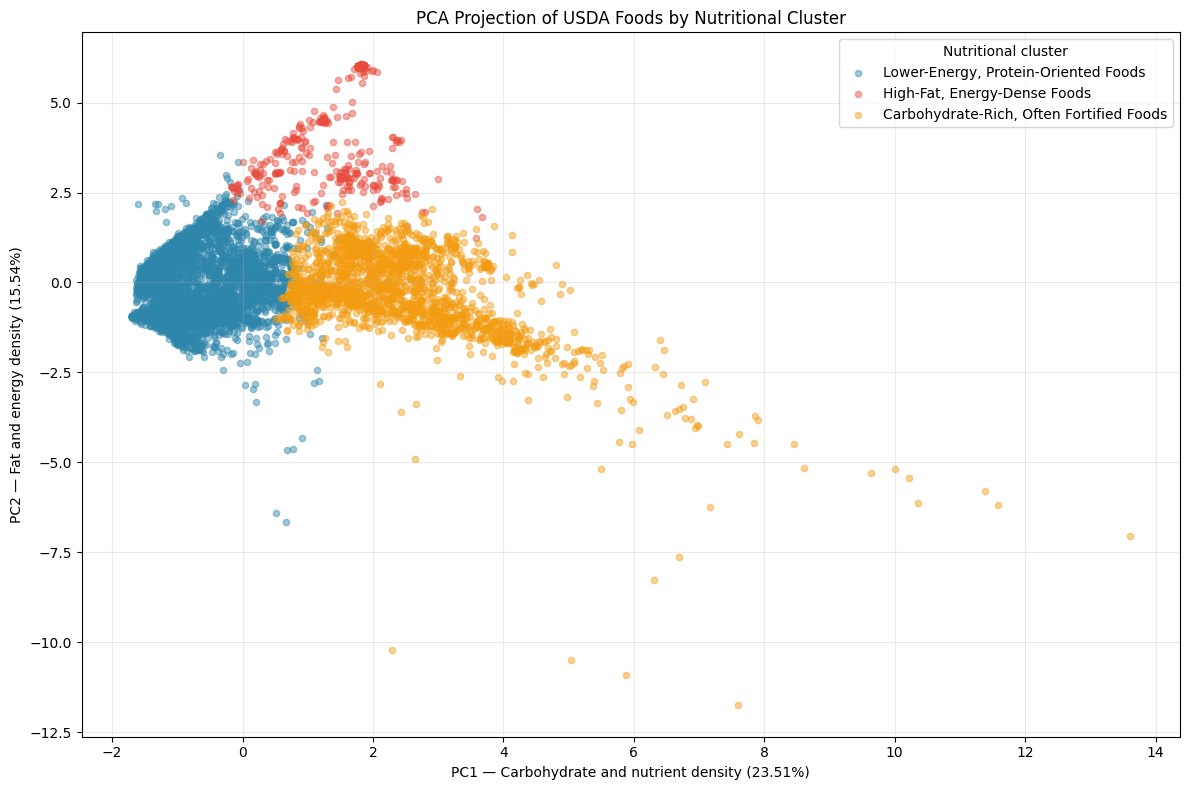

In [44]:
pca_df["Cluster_Name"] = (
    pca_df["Cluster"].map(cluster_names)
)

colours = {
    0: "#2E86AB",
    1: "#E74C3C",
    2: "#F39C12"
}

plt.figure(figsize=(12, 8))

for cluster in sorted(pca_df["Cluster"].unique()):

    subset = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=cluster_names[cluster],
        color=colours[cluster],
        alpha=0.45,
        s=20
    )

plt.xlabel(
    f"PC1 — Carbohydrate and nutrient density "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

plt.ylabel(
    f"PC2 — Fat and energy density "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

plt.title(
    "PCA Projection of USDA Foods by Nutritional Cluster"
)

plt.legend(title="Nutritional cluster")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation of the PCA projection

The first two principal components explain 39.05% of the total variance.
PC1, which explains 23.51%, is primarily associated with carbohydrates,
energy, sugar, fibre and minerals. It can therefore be interpreted as a
carbohydrate and nutrient-density dimension.

PC2 explains 15.54% of the variance and is primarily influenced by fat and
energy content. It can therefore be interpreted as a fat and energy-density
dimension.

The high-fat, energy-dense cluster occupies the upper area of the projection,
while carbohydrate-rich, often fortified foods extend towards higher PC1
values. Lower-energy, protein-oriented foods are concentrated mainly at lower
PC1 values. Some overlap is expected because the two-dimensional projection
represents only 39.05% of the full eleven-dimensional nutritional information.
The clustering itself was performed using all eleven standardised variables.

PCA Validation of K-Means Clusters

To validate and visualise the K-Means clustering results, a Principal Component Analysis (PCA) was applied to the scaled nutritional data. PCA reduces the original 11-dimensional nutrient space (calories, protein, fat, carbohydrates, sugar, fibre, sodium, calcium, iron, vitamin C and vitamin A) into two orthogonal components that capture the main directions of variation across foods.

Each point in the PCA plot represents a food item. The distance between points reflects nutritional similarity, and colours indicate the K-Means cluster assignments.

***Interpretation of the PCA axes***

Principal Component 1 (PC1) primarily represents an energy and macronutrient density axis, separating low-energy, protein-focused foods from high-energy foods rich in fat and carbohydrates.

Principal Component 2 (PC2) captures a fat versus carbohydrate-micronutrient gradient, separating fat-dominated foods from carbohydrate- and vitamin-rich foods.

***Cluster structure in PCA space***

The PCA projection reveals three clearly structured regions:

Cluster 0 (Protein-rich foods) appears on the left side of the plot. These foods have lower energy density and relatively higher protein content (e.g., cheeses and protein-focused dairy products).

Cluster 1 (Fat-dense foods) occupies the upper region of the plot, indicating very high fat and energy content (e.g., butter, oils, egg yolk, lard).

Cluster 2 (Carbohydrate and micronutrient-rich foods) extends to the right and downward, reflecting foods with high carbohydrate, sugar, fibre, and vitamin content (e.g., milk powders, whey, sweetened and plant-based foods

**Scientific validatio***

The clear spatial separation of the three clusters in PCA space confirms that K-Means successfully identified distinct nutritional regimes rather than arbitrary groups. Foods with similar nutrient compositions cluster together, and the boundaries between protein-dominated, fat-dominated, and carbohydrate-micronutrient-dominated foods are clearly visible.

This provides strong geometric and nutritional validation of the unsupervised learning results.

______________________________________________________________________

Association Rules on USDA Foods

Already foods had been clustered by nutrients.
Now we are going to  discover nutrient co-occurrence patterns inside foods.

Example:

“High-protein foods are usually high in calcium”
“High-fat foods are rarely high in vitamin C”

These are discovered automatically by Apriori.

Goal:

Discover frequent nutritional patterns that occur together in foods in order to identify hidden dietary relationships.

This helps:  diet design. food substitution. nutritional labelling. food recommendation systems
How to prepare the data (very important)

Apriori does not work with continuous numbers.
It needs binary items (present / not present).

So we have to convert nutrients into categories like:  High protein. High fat. High sugar. High vitamin C
Each food becomes a “basket” of nutrition tags.
Example:
CHEESE → {High protein, High fat, High calcium}
APPLE → {High carbs, High vitamin C, Low fat}

Cell 23 — Convert nutrients into binary food tags. 
**The Apriori algorithm does not work with continuous numbers such as:**
   - 147 kcal
   - 12.4 g protein
   - 246 mg sodium
Solution:
We convert each nutrient to a binary state:
  - 1 =is High
  - 0 = Not high

In [45]:
# Convert continuous nutrients into high-nutrient indicators

nutrient_cols = X_raw.columns

# Use the 75th percentile instead of the median
# A food is "high" when its value exceeds Q3
thresholds = X_raw.quantile(0.75)

binary_df = X_raw.gt(thresholds).astype(bool)

binary_df.columns = [
    "High_" + column
    for column in nutrient_cols
]

threshold_table = pd.DataFrame({
    "Nutrient": nutrient_cols,
    "High_Threshold_Q3": thresholds.values,
    "Foods_Classified_High": binary_df.sum().values,
    "Percentage_High": (
        binary_df.mean().values * 100
    )
})

threshold_table.round(2)

,Nutrient,High_Threshold_Q3,Foods_Classified_High,Percentage_High
0,Energ_Kcal,337.00,2186,24.87
1,Protein_(g),19.88,2197,25.00
2,Lipid_Tot_(g),13.72,2197,25.00
3,Carbohydrt_(g),34.95,2197,25.00
4,Sugar_Tot_(g),6.06,2195,24.98
5,Fiber_TD_(g),2.40,2130,24.24
6,Sodium_(mg),401.00,2192,24.94
7,Calcium_(mg),64.00,2194,24.97
8,Iron_(mg),2.57,2196,24.99
9,Vit_C_(mg),2.50,2183,24.84


Cell 24 — Convert to transactions for Apriori

In [46]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    binary_df,
    min_support=0.05,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

print(
    "Number of frequent itemsets:",
    len(frequent_itemsets)
)

frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(15)

Number of frequent itemsets: 84


,support,itemsets
10,0.250000,(High_Vit_A_IU)
2,0.250000,(High_Lipid_Tot_(g))
3,0.250000,(High_Carbohydrt_(g))
1,0.250000,(High_Protein_(g))
8,0.249886,(High_Iron_(mg))
4,0.249772,(High_Sugar_Tot_(g))
7,0.249659,(High_Calcium_(mg))
6,0.249431,(High_Sodium_(mg))
0,0.248748,(High_Energ_Kcal)
9,0.248407,(High_Vit_C_(mg))


,support,itemsets
6,0.500000,frozenset({High_Protein_(g)})
1,0.500000,frozenset({High_Carbohydrt_(g)})
5,0.499886,frozenset({High_Lipid_Tot_(g)})
2,0.498748,frozenset({High_Energ_Kcal})
7,0.493741,frozenset({High_Sodium_(mg)})
4,0.490783,frozenset({High_Iron_(mg)})
0,0.472918,frozenset({High_Calcium_(mg)})
3,0.463928,frozenset({High_Fiber_TD_(g)})
9,0.458239,frozenset({High_Vit_A_IU})
10,0.441511,frozenset({High_Vit_C_(mg)})


In [47]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.20
)

interpretable_rules = rules[
    (rules["support"] >= 0.05) &
    (rules["confidence"] >= 0.60) &
    (rules["lift"] >= 1.20) &
    (rules["antecedents"].apply(len) <= 2) &
    (rules["consequents"].apply(len) == 1)
].copy()

interpretable_rules = interpretable_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
)

print("All generated rules:", len(rules))
print("Interpretable rules:", len(interpretable_rules))

interpretable_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

All generated rules: 240
Interpretable rules: 44


,antecedents,consequents,support,confidence,lift
60,"(High_Lipid_Tot_(g), High_Carbohydrt_(g))",(High_Energ_Kcal),0.082954,0.968127,3.891997
85,"(High_Sugar_Tot_(g), High_Energ_Kcal)",(High_Carbohydrt_(g)),0.117091,0.959888,3.839552
180,"(High_Sugar_Tot_(g), High_Iron_(mg))",(High_Carbohydrt_(g)),0.080451,0.948993,3.795973
66,"(High_Sugar_Tot_(g), High_Lipid_Tot_(g))",(High_Energ_Kcal),0.061334,0.918228,3.691395
73,"(High_Lipid_Tot_(g), High_Fiber_TD_(g))",(High_Energ_Kcal),0.054620,0.914286,3.675546
92,"(High_Energ_Kcal, High_Fiber_TD_(g))",(High_Carbohydrt_(g)),0.104916,0.881453,3.525813
109,"(High_Iron_(mg), High_Energ_Kcal)",(High_Carbohydrt_(g)),0.103550,0.880077,3.520309
156,"(High_Sugar_Tot_(g), High_Lipid_Tot_(g))",(High_Carbohydrt_(g)),0.057579,0.862010,3.448041
163,"(High_Sugar_Tot_(g), High_Fiber_TD_(g))",(High_Carbohydrt_(g)),0.078402,0.836165,3.344660
126,"(High_Sugar_Tot_(g), High_Iron_(mg))",(High_Energ_Kcal),0.069413,0.818792,3.291649


In [48]:
def items_to_text(itemset):
    return ", ".join(
        sorted(
            item.replace("High_", "")
            for item in itemset
        )
    )

rules_readable = interpretable_rules.copy()

rules_readable["IF"] = (
    rules_readable["antecedents"]
    .apply(items_to_text)
)

rules_readable["THEN"] = (
    rules_readable["consequents"]
    .apply(items_to_text)
)

top_rules = rules_readable[
    [
        "IF",
        "THEN",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

top_rules.round(3)

,IF,THEN,support,confidence,lift
60,"Carbohydrt_(g), Lipid_Tot_(g)",Energ_Kcal,0.083,0.968,3.892
85,"Energ_Kcal, Sugar_Tot_(g)",Carbohydrt_(g),0.117,0.960,3.840
180,"Iron_(mg), Sugar_Tot_(g)",Carbohydrt_(g),0.080,0.949,3.796
66,"Lipid_Tot_(g), Sugar_Tot_(g)",Energ_Kcal,0.061,0.918,3.691
73,"Fiber_TD_(g), Lipid_Tot_(g)",Energ_Kcal,0.055,0.914,3.676
92,"Energ_Kcal, Fiber_TD_(g)",Carbohydrt_(g),0.105,0.881,3.526
109,"Energ_Kcal, Iron_(mg)",Carbohydrt_(g),0.104,0.880,3.520
156,"Lipid_Tot_(g), Sugar_Tot_(g)",Carbohydrt_(g),0.058,0.862,3.448
163,"Fiber_TD_(g), Sugar_Tot_(g)",Carbohydrt_(g),0.078,0.836,3.345
126,"Iron_(mg), Sugar_Tot_(g)",Energ_Kcal,0.069,0.819,3.292


Cell 27 — Sort rules by strength (Lift)

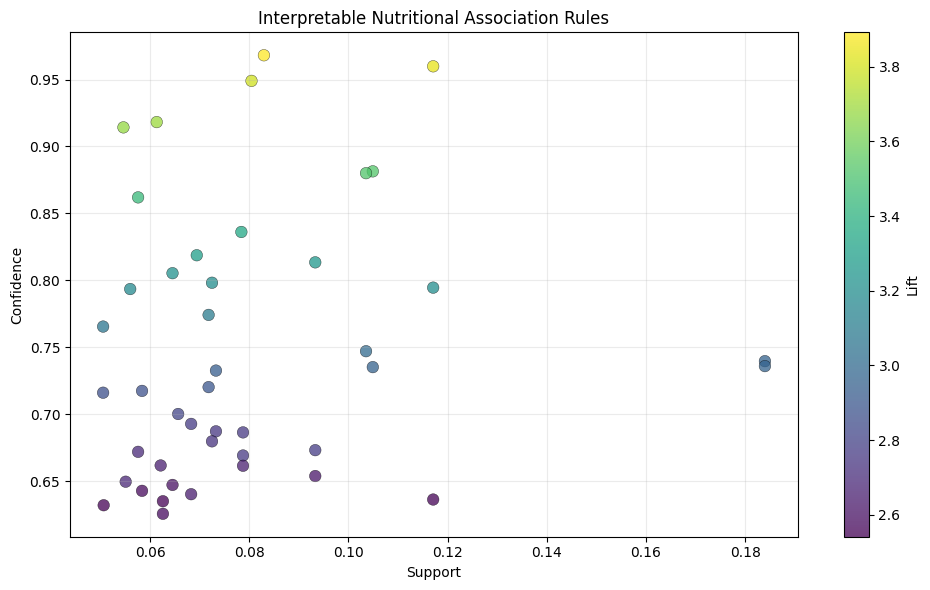

In [49]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    interpretable_rules["support"],
    interpretable_rules["confidence"],
    c=interpretable_rules["lift"],
    cmap="viridis",
    s=70,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3
)

plt.colorbar(
    scatter,
    label="Lift"
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title(
    "Interpretable Nutritional Association Rules"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

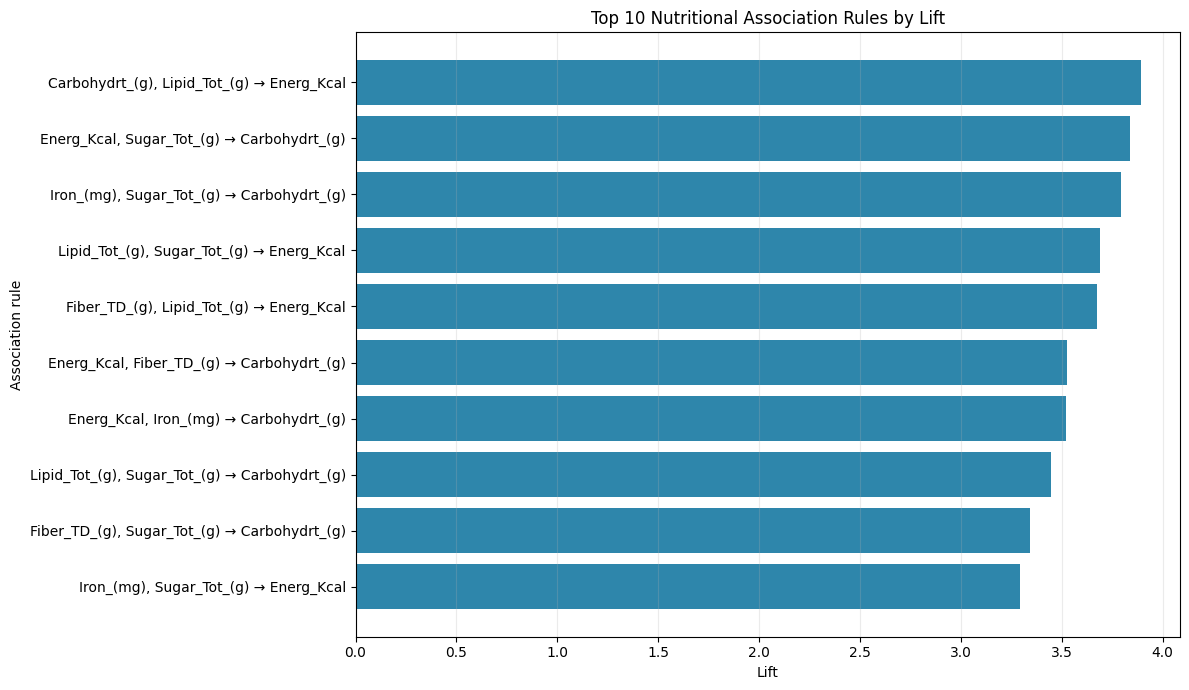

In [50]:
top10_rules = rules_readable.head(10).copy()

top10_rules["Rule"] = (
    top10_rules["IF"] +
    " → " +
    top10_rules["THEN"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    top10_rules["Rule"],
    top10_rules["lift"],
    color="#2E86AB"
)

plt.xlabel("Lift")
plt.ylabel("Association rule")
plt.title("Top 10 Nutritional Association Rules by Lift")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [51]:
from pathlib import Path

output_directory = Path("outputs")
output_directory.mkdir(exist_ok=True)

# Complete food and cluster assignments
results.to_csv(
    output_directory / "clustered_foods.csv",
    index=False
)

# Cluster nutritional profiles
profile_summary.to_csv(
    output_directory / "cluster_profiles.csv"
)

# Preprocessing comparison
comparison_df.to_csv(
    output_directory / "preprocessing_comparison.csv",
    index=False
)

# Clustering algorithm comparison
model_comparison_df.to_csv(
    output_directory / "clustering_model_comparison.csv",
    index=False
)

# K-means stability results
stability_df.to_csv(
    output_directory / "kmeans_stability.csv",
    index=False
)

# PCA results
pca_variance_df.to_csv(
    output_directory / "pca_explained_variance.csv",
    index=False
)

pca_loadings.to_csv(
    output_directory / "pca_loadings.csv"
)

# Interpretable association rules
rules_readable[
    [
        "IF",
        "THEN",
        "support",
        "confidence",
        "lift"
    ]
].to_csv(
    output_directory / "association_rules.csv",
    index=False
)

print("Results saved successfully:")

for file in sorted(output_directory.iterdir()):
    print("-", file)

Results saved successfully:
- outputs/association_rules.csv
- outputs/cluster_profiles.csv
- outputs/clustered_foods.csv
- outputs/clustering_model_comparison.csv
- outputs/kmeans_stability.csv
- outputs/pca_explained_variance.csv
- outputs/pca_loadings.csv
- outputs/preprocessing_comparison.csv


In [52]:
from pathlib import Path

output_directory = Path("outputs").resolve()

print("Your files are located here:")
print(output_directory)

Your files are located here:
/Users/salimhoumaidan/Desktop/outputs


## Limitations

The results depend on the selected nutritional variables, preprocessing
decisions and assumptions of the K-Means algorithm. K-Means assumes
approximately spherical clusters and may not capture more complex structures.

The three identified clusters should therefore be interpreted as exploratory
patterns rather than definitive nutritional categories.

The association rules also depend on the median-based thresholds used to
convert continuous nutritional values into binary high/low categories.
Different thresholds may produce different rules.

## Conclusion

This project applied unsupervised learning and association-rule mining to
explore nutritional patterns in a USDA food dataset.

After preprocessing and standardising 11 nutritional variables, K-Means
clustering was evaluated using the elbow method and silhouette score. A
three-cluster solution produced the highest silhouette score of approximately
0.427.

PCA was used to visualise the resulting clusters, while Apriori association-rule
mining was used to investigate relationships between high-value nutritional
properties.

The project demonstrates a complete introductory data-analysis workflow,
including data cleaning, feature engineering, model selection, evaluation,
visualisation and interpretation.